In [2]:
pip install tensorflow

   ---------------------------------------- 0.0/332.0 MB ? eta -:--:--
   ---------------------------------------- 3.9/332.0 MB 27.0 MB/s eta 0:00:13
   - -------------------------------------- 10.2/332.0 MB 25.4 MB/s eta 0:00:13
   - -------------------------------------- 14.4/332.0 MB 23.8 MB/s eta 0:00:14
   -- ------------------------------------- 18.6/332.0 MB 22.7 MB/s eta 0:00:14
   -- ------------------------------------- 22.5/332.0 MB 21.7 MB/s eta 0:00:15
   --- ------------------------------------ 27.0/332.0 MB 22.3 MB/s eta 0:00:14
   --- ------------------------------------ 32.0/332.0 MB 22.0 MB/s eta 0:00:14
   ---- ----------------------------------- 37.2/332.0 MB 22.4 MB/s eta 0:00:14
   ---- ----------------------------------- 41.4/332.0 MB 22.3 MB/s eta 0:00:14
   ----- ---------------------------------- 44.8/332.0 MB 21.7 MB/s eta 0:00:14
   ------ --------------------------------- 49.8/332.0 MB 21.8 MB/s eta 0:00:13
   ------ --------------------------------- 54.3/3

In [3]:
# American Sign Language Detection
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

import kagglehub

# Misc
import warnings
warnings.filterwarnings("ignore")

In [4]:
# Download latest version of ASL dataset
path = kagglehub.dataset_download("grassknoted/asl-alphabet")
print("Path to dataset files:", path)

100%|██████████| 1.03G/1.03G [01:07<00:00, 16.4MB/s]

Extracting files...


Path to dataset files: C:\Users\DipaliAgrawal\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1


In [5]:
# Set paths for train and test sets
train_path = os.path.join(path, "asl_alphabet_train")
test_path = os.path.join(path, "asl_alphabet_test")

# List classes
classes = sorted(os.listdir(train_path))
print("Detected Classes:", classes)
print("Total Classes:", len(classes))

# Count images per class
for cls in classes[:5]:  # Display first 5 classes
    print(cls, ":", len(os.listdir(os.path.join(train_path, cls))), "images")

Detected Classes: ['asl_alphabet_train']
Total Classes: 1
asl_alphabet_train : 29 images


In [6]:
# Image size
IMG_HEIGHT, IMG_WIDTH = 64, 64
BATCH_SIZE = 32

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

# Train generator
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Validation generator
val_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 69600 images belonging to 1 classes.
Found 17400 images belonging to 1 classes.


In [7]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(len(classes), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,274,305 (4.86 MB)

 Trainable params: 1,273,857 (4.86 MB)

 Non-trainable params: 448 (1.75 KB)

In [10]:
# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint("asl_model.h5", monitor='val_accuracy', save_best_only=True)

# Train
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=1, # Change to 20-25 for better results
    callbacks=[early_stop, checkpoint]
)

2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 1.0000 - loss: 0.0000e+00

2175/2175 ━━━━━━━━━━━━━━━━━━━━ 930s 428ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00


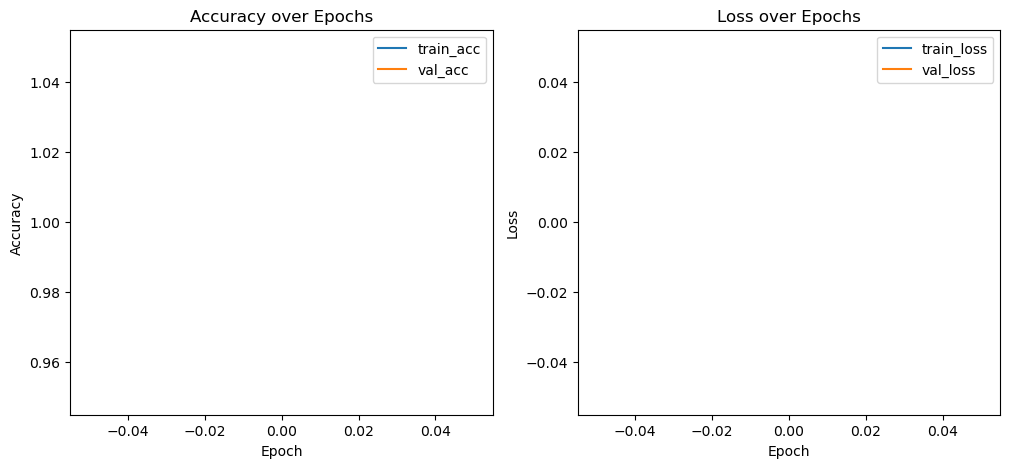

In [12]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [13]:
# Test generator
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Evaluate
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc*100:.2f}%")

Found 28 images belonging to 1 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Test Accuracy: 100.00%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


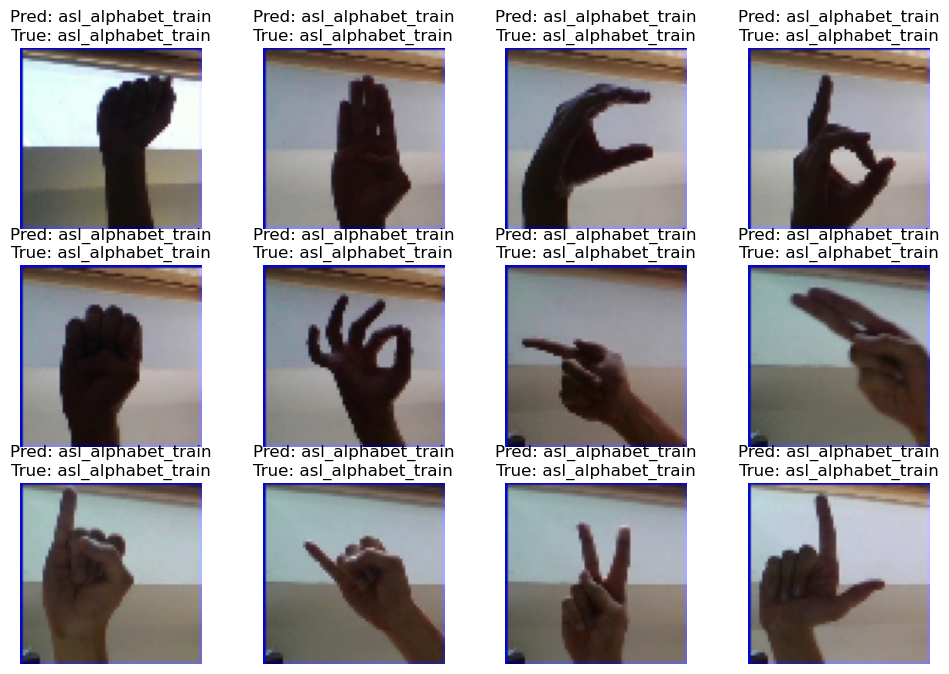

In [20]:
# Load some test images
sample_imgs, sample_labels = next(test_generator)

preds = model.predict(sample_imgs)
pred_classes = np.argmax(preds, axis=1)
true_classes = np.argmax(sample_labels, axis=1)

# Display a few predictions
plt.figure(figsize=(12,8))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(sample_imgs[i])
    plt.title(f"Pred: {classes[pred_classes[i]]}\nTrue: {classes[true_classes[i]]}")
    plt.axis('off')
plt.show()

In [15]:
model.save("asl_model_final.h5")
print("ASL Detection model saved successfully!")

ASL Detection model saved successfully!
